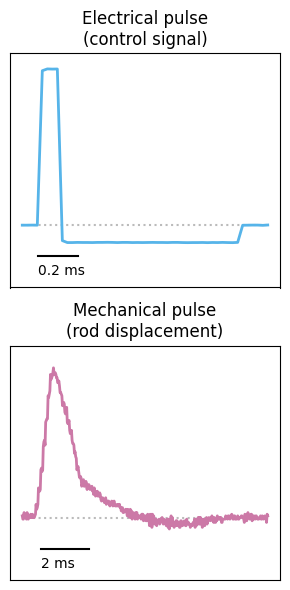

In [4]:
import adi
import matplotlib.pyplot as plt
import numpy as np
from scipy import signal

import hff_analysis
import hff_analysis.classes as classes
import hff_analysis.constants as constants
import hff_analysis.utils as utils

files = [
    ('hff08_pos1_freqsweep', 1)
]
elec_frequencies = {10: 0}
mech_frequencies = {10: 1}

def plot_stim_shape(
        trace,
        trigger_signal,
        trigger_value: float,
        plot_duration: int,
        start: int,
        row: int,
        colour: str,
        title: str,
        flip: bool
):
    end = int(start+10/tick_dt)
    triggers = hff_analysis.spike_extraction.triggers(
        trigger_signal[start:end],
        trigger_value
    )
    start_sample = triggers[0]
    trial = trace[start:end]
    if flip:
        norm = [x/min(trial) for x in trial[start_sample:start_sample+plot_duration+10]]
    else:
        norm = [x/max(trial) for x in trial[start_sample:start_sample+plot_duration+10]]
    x = [i*tick_dt*constants.core.MILLISECONDS_PER_SECOND for i in range(0,len(norm))]
    ax = axes[row]
    ax.plot(
        x,
        np.zeros(len(x)),
        c=constants.plots.PALETTE['light_grey'],
        lw=1.5,
        ls='dotted',
        zorder=0
    )
    ax.plot(
        x,
        norm,
        c=constants.plots.PALETTE[colour],
        lw=2,
        zorder=1
    )
    x_scale = plot_duration*tick_dt*constants.core.MILLISECONDS_PER_SECOND/5
    x_scale_offset = x_scale * 0.4
    x_scale_pos = -0.2
    x_scalelabel_pos = x_scale_pos - 0.05
    x_scalelabel = int(x_scale) if int(x_scale) == x_scale else x_scale
    ax.plot(
        (x_scale_offset, x_scale+x_scale_offset),
        (x_scale_pos, x_scale_pos),
        c=constants.plots.PALETTE['black'],
        zorder=2
    )
    ax.text(
        x_scale_offset,
        x_scalelabel_pos,
        f"{x_scalelabel} ms",
        va='top'
    )
    plt.setp(ax, ylim=[-0.4, 1.1], xticks=[], yticks=[], title=title)

for (filename, segment) in files:
    filename_info = classes.FilenameInfo.from_filename(filename)
    data = adi.read_file(
        constants.core.RAW_DATA_PATH + filename_info.animal_id + '\\' +
        filename_info.name + filename_info.extension
    )
    record = data.records[segment]
    tick_dt = record.tick_dt
    laser_trace = data.channels[3].get_data(segment+1)
    mech_trigger = data.channels[1].get_data(segment+1)
    elec_trace = data.channels[2].get_data(segment+1)
    trigger_value_mech = round(max(mech_trigger), 1) * constants.core.TRIGGER_DETECTION_NOISE_WINDOW
    trigger_value_elec = round(max(elec_trace), 1) * constants.core.TRIGGER_DETECTION_NOISE_WINDOW
    f, axes = plt.subplots(2, 1, figsize=(3,6))
    for i, comment in enumerate(record.comments):
        start = int(comment.time/tick_dt)
        p = hff_analysis.spike_extraction.sweep_pattern
        m = p.search(comment.text)
        elec_frequency = int(m.group('elecval'))
        if elec_frequency in elec_frequencies.keys():
            plot_stim_shape(
                elec_trace,
                elec_trace,
                trigger_value_elec,
                int(0.001/tick_dt),
                start,
                elec_frequencies[elec_frequency],
                'sky',
                "Electrical pulse\n(control signal)",
                False
            )
        mech_frequency = int(m.group('mechval'))
        if mech_frequency in mech_frequencies.keys():
            plot_stim_shape(
                laser_trace,
                mech_trigger,
                trigger_value_mech,
                int(0.01/tick_dt),
                start,
                mech_frequencies[mech_frequency],
                'pink',
                "Mechanical pulse\n(rod displacement)",
                True
            )
    plt.tight_layout()
    utils.save_plot(
        'paper',
        "Figure 1"
    )